### 监督学习:在给定正确答案的情况下,建立从输入到输出的映射

1.回归:从无穷连续数字中预测一个正确的数字<br>
e.g.房价预测<br>
2.分类:从有限离散数字中预测有限离散的数字<br>
e.g.肿瘤良性恶性判断

### 无监督学习:在不给定每个数据标签的情况下,寻找数据集中的结构(不给定输出,只给输入)

1.聚类(clustering):将所有的数据分为簇<br>
e.g.在操场上,大家自由活动,由机器给他们分类(你没告诉谁和谁认识,以及他们在干什么)<br>
2.异常检测:发现数据集的异常数据<br>
3.降维:在尽量不损失信息的情况下,将大量的数据集变为小数据集

$$f_{w,b}(x)=wx+b=\hat{y}$$

### 代价函数

平方误差代价函数:(注意谁是谁的函数,注意谁是给定的)

$$J(w,b)=\frac{1}{2m}\sum_{i=1}^{m}(\hat{y}^{(i)}-y^{(i)})^2=\frac{1}{2m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)})-y^{(i)})^2$$

目标就是最小化$J(w,b)$

固定不同的b(切片),得到平面直角坐标系的二次函数<br>三维图:<br>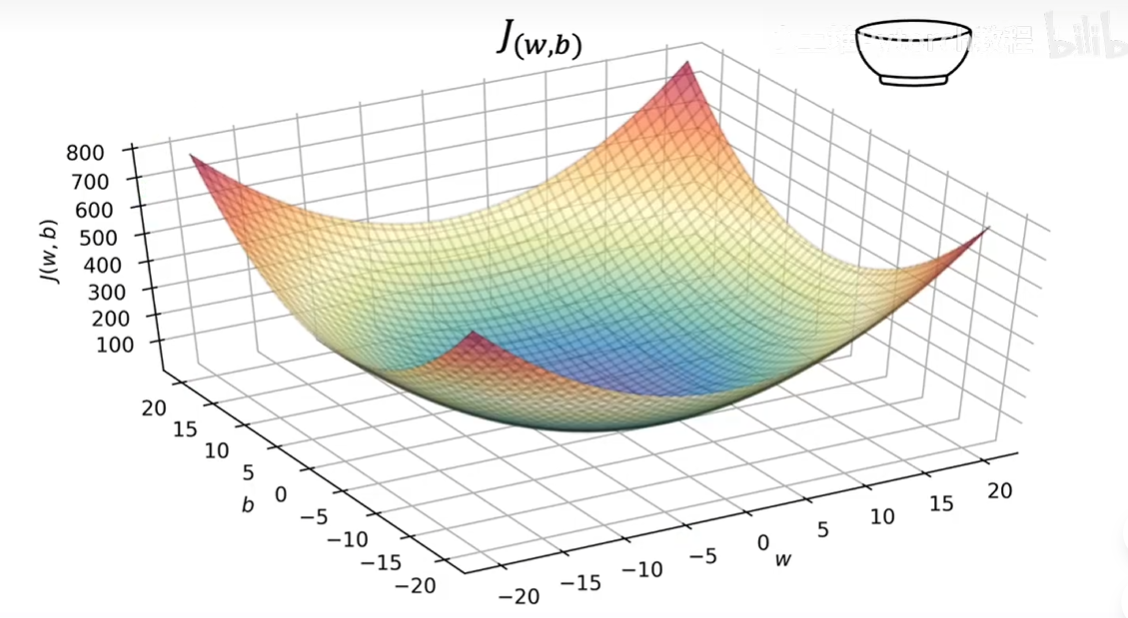<br>等高线图:<br>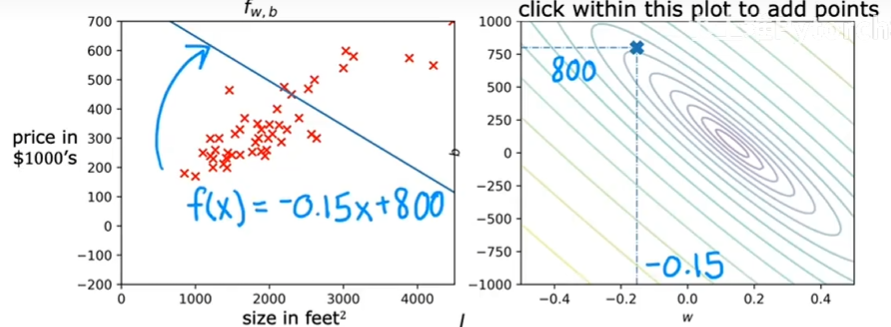

### 梯度下降:寻找最快的下降方向

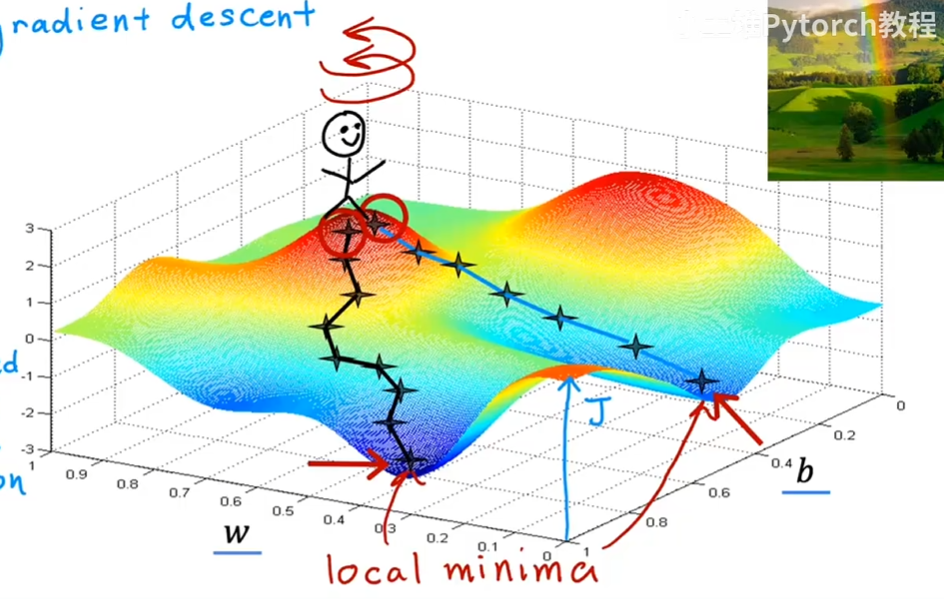

$$w_{new}=w-\alpha\frac{\partial}{\partial w}J(w,b)$$
$$b_{new}=b-\alpha\frac{\partial}{\partial b}J(w,b)$$
注意这里$w_{new}$和$b_{new}$是**同时得到**的,你不能先更新$w$然后把他传入用来更新$b$

### 线性回归的梯度下降

$$w_{new}=w-\alpha\frac{1}{m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)})-y^{(i)})x^{(i)}$$
$$b_{new}=b-\alpha\frac{1}{m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)})-y^{(i)})$$

对于这种情况:local minium=golbal minium

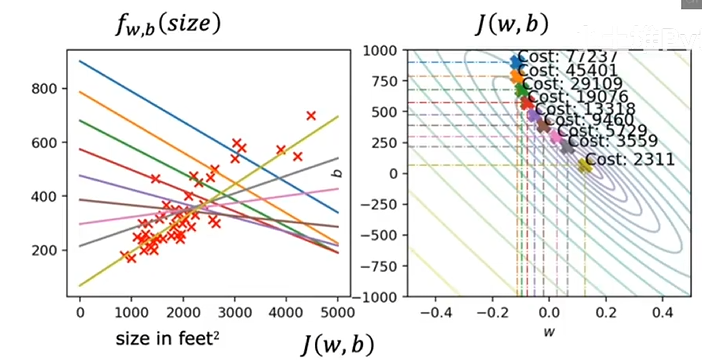

这是Batch梯度下降,我们计算的是所有数据的梯度,我们还有随机梯度下降

### 多特征

在预测房价的时候,我们不仅需要房屋大小,还要许多特征$x_1,x_2,x_3...$

符号:n是特征数量,$\vec(x)^{(2)}=[x_1^{(2)},x_2^{(2)},...]$

$$f_{\boldsymbol {w},b}(\boldsymbol {x})=\sum_{i=1}^nw_ix_i+b=\boldsymbol {w}\boldsymbol {x}+b$$

$w_i$可以理解为每个$x_i$的权重,例如房子面积涨100,价格多1k,多一个客厅,价格多10k,...

### 向量化

In [1]:
import numpy as np

numpy可以并行运行点积,会比用for循环算的更快(much more)

In [11]:
w,x,f=list(range(1,1000000)),list(range(1000001,2000000)),0
for j in range(0,999999):
    f=f+w[j]*x[j]
print(f)

833332333333500000


In [12]:
print(np.dot(w,x))

833332333333500000


正规方程!(只是适用于线性回归——本质是最小二乘法):$$A^TA\hat{x}=A^TB$$

### 特征放缩

$\hat{price}=w_1x_1+w_2x_2+b$其中$x_1$是房子大小(300-2000feet^2),$x_2$是卧室数量(0-5)

如果w1=50,w2=0.1,b=50,结果就是1亿;如果w1=0.1,w2=50,b=50,结果就是50万.如此进行会导致J的等高线图非常扁,导致在扁的方向难以收敛
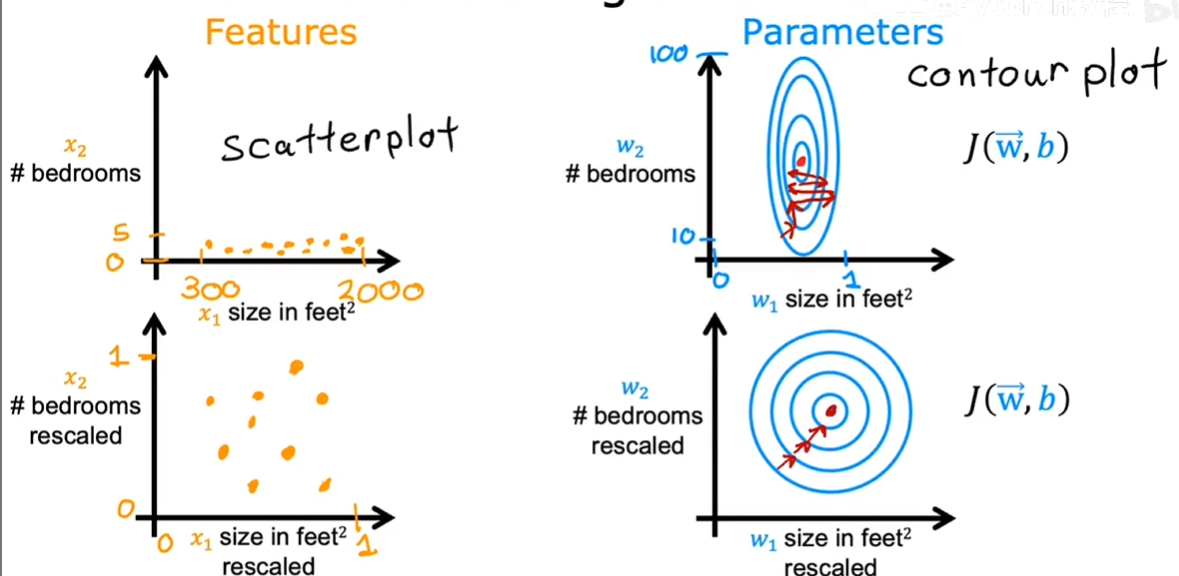

最大值归一化:$\frac{x_1}{2000}\in[0.15,1],\frac{x_2}{5}\in[0,1]$<br>
均值归一化:$\frac{x_1-\bar{x_1}}{max-min},\frac{x_2-\bar{x_2}}{max-min}$<br>
Z-Score归一化:$\frac{x_1-\bar{x_1}}{\sigma_1},\frac{x_2-\bar{x_2}}{\sigma_2}$<br>

### 检查代价函数是否收敛

学习曲线——J(w,b)-#iterations,增加说明代码错误或者学习率不合适

如果梯度下降不对,可以将$\alpha$设置为非常小的数字,观察Learning Curve是否下降,看看问题

### Feature engineering

创建一个新的特征,使模型在现实中可以更精准的预测:房子的长和宽决定形状和面积,这都是购房的时候需要考虑的点: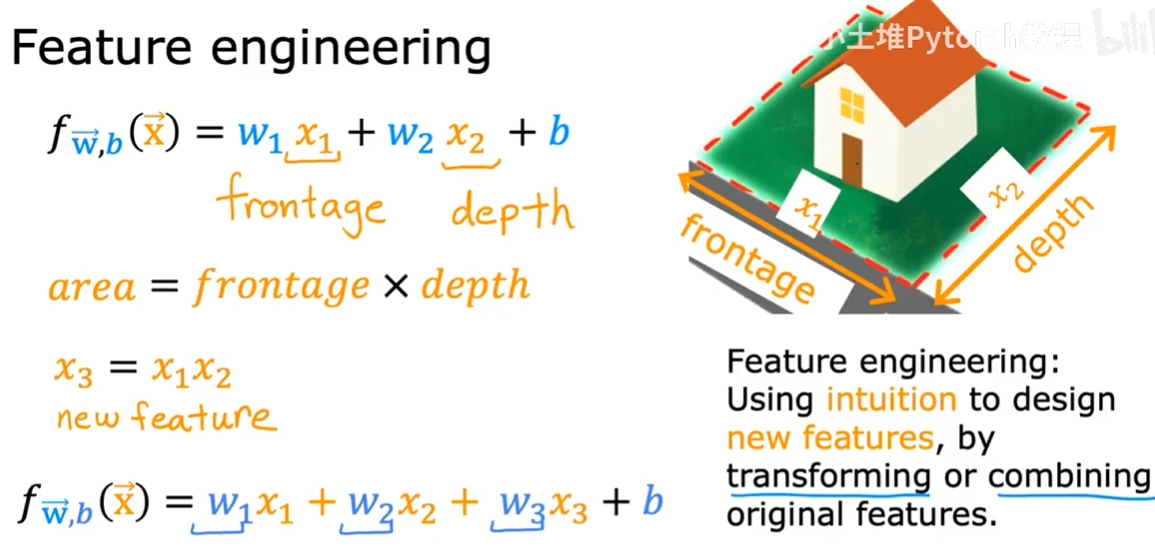

### 多项式回归

这里会发现特征放缩非常重要,没有放缩的会被高次项及其大量放大

如何选择多项式特征,我们后面再说

### 逻辑回归(应该叫"分类")

判断垃圾邮件:答案只有是\否<br>
0\false:negative class<br>
1\true:positive class

线性回归在分类中会因为某些实际上不影响分类的数据被影响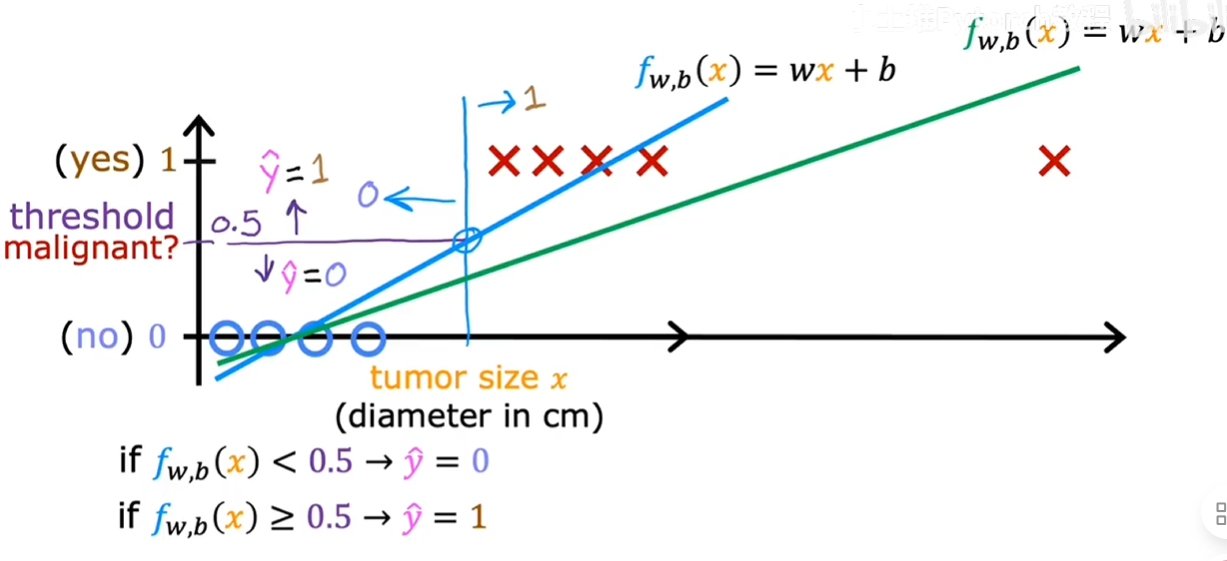

$$f_{\boldsymbol {w},b}(\boldsymbol {x})=\boldsymbol {w}\boldsymbol {x}+b$$and sigmoid function:$$g(z)=\frac{1}{1+e^{-z}}$$

在肿瘤的良性恶性判断中,x是肿瘤大小,y是0(良性)或1(恶性),我们得到$f_{\boldsymbol {w},b}(\boldsymbol {x})=0.7$意思就是是恶性的概率为0.7

$$f_{\boldsymbol {w},b}(\boldsymbol {x})=g(\boldsymbol{w}\boldsymbol {x}+b)=\frac{1}{1+e^{-(\boldsymbol {w}\boldsymbol {x}+b)}}=P(y=1|\boldsymbol {x};\boldsymbol{w},b)$$
如果我们选择0.5为良性恶性的分界点，那么:$f_{\boldsymbol {w},b}(\boldsymbol {x})\geq 0.5$也即$\boldsymbol {w}\boldsymbol {x}+b\geq 0$

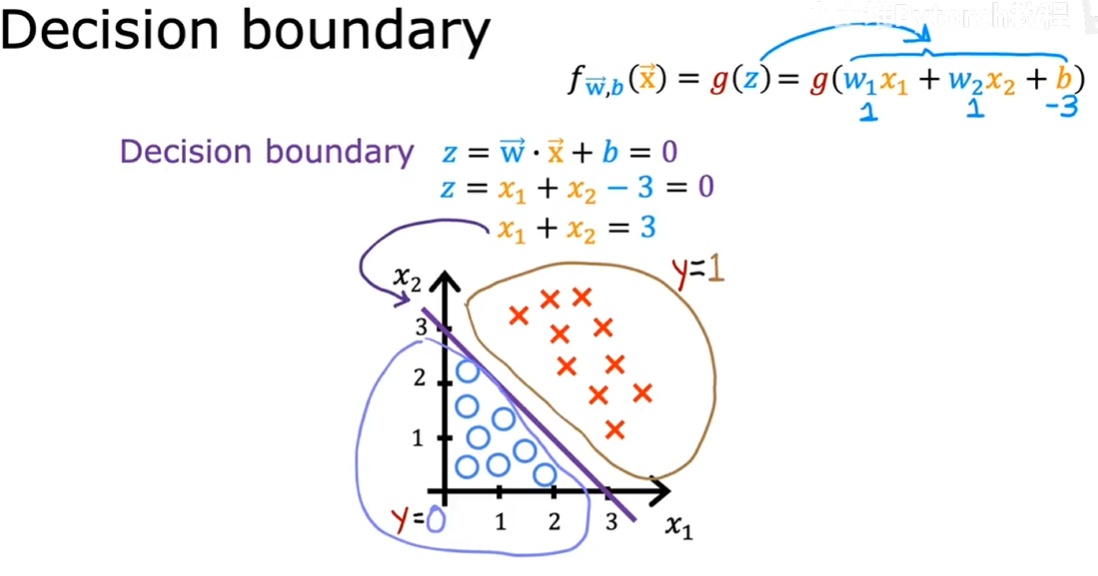

或者我们有非线性决策边界,传入g(z)的特征为多项式: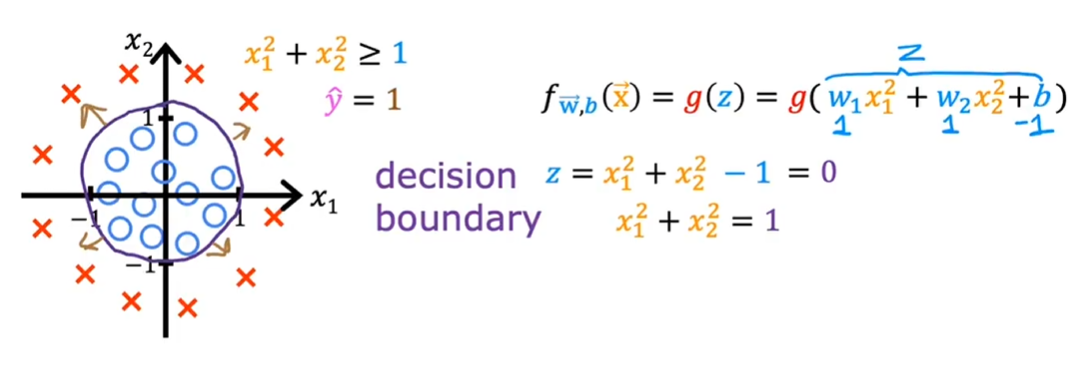

我自己的一些思考:逻辑回归假设概率经过 logit（即 sigmoid 的反函数）变换后，落在线性函数$w^⊤x$所张成的空间中，并通过最大似然估计来学习参数。<br>
模型找到了一个最佳线性函数，这个线性函数对我的数据给的一个值，经过sigmoid函数，会变成一个倾向程度(先算一个数$z = wx + b$再$s = sigmoid(z)$(这里的s是模型的倾向程度))

### 逻辑回归的成本函数

如果用平方误差代价函数: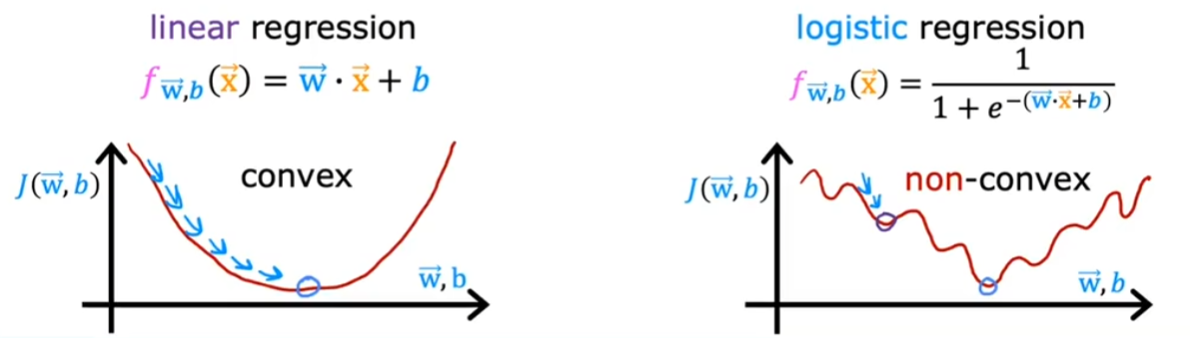

定义损失:$$L(f_{\boldsymbol {w},b}(\boldsymbol {x}^{(i)}),y^{(i)})=\frac{1}{2}(f_{\boldsymbol {w},b}(\boldsymbol {x}^{(i)})-y^{(i)})^2$$

逻辑回归的损失:

$$L(f_{\boldsymbol {w},b}(\boldsymbol {x}^{(i)}),y^{(i)})=-\log{(y^{(i)}+(-1)^{y^{(i)}-1}f_{\boldsymbol {w},b}(\boldsymbol {x}^{(i)}))}$$

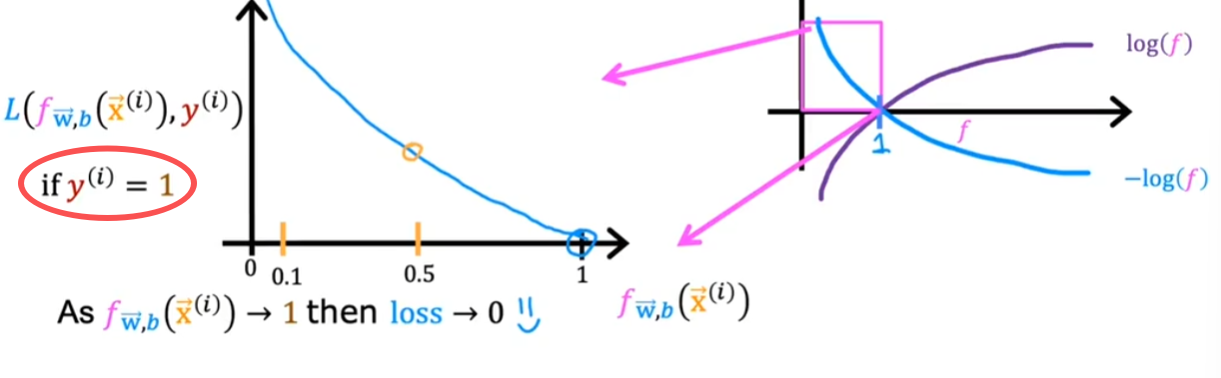

y为0的时候,我输出的倾向更为1那么随时就越高

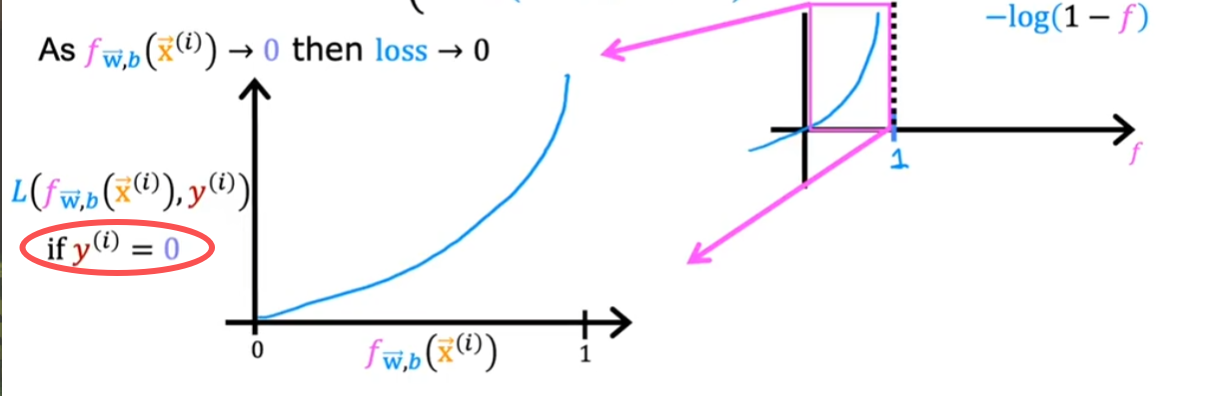

我们看看三维图中使用平方误差代价函数的逻辑回归代价函数: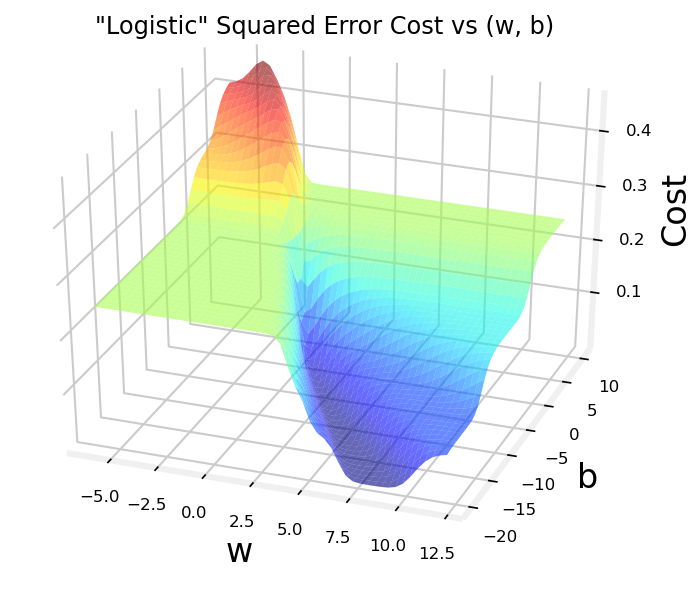

这是使用交叉熵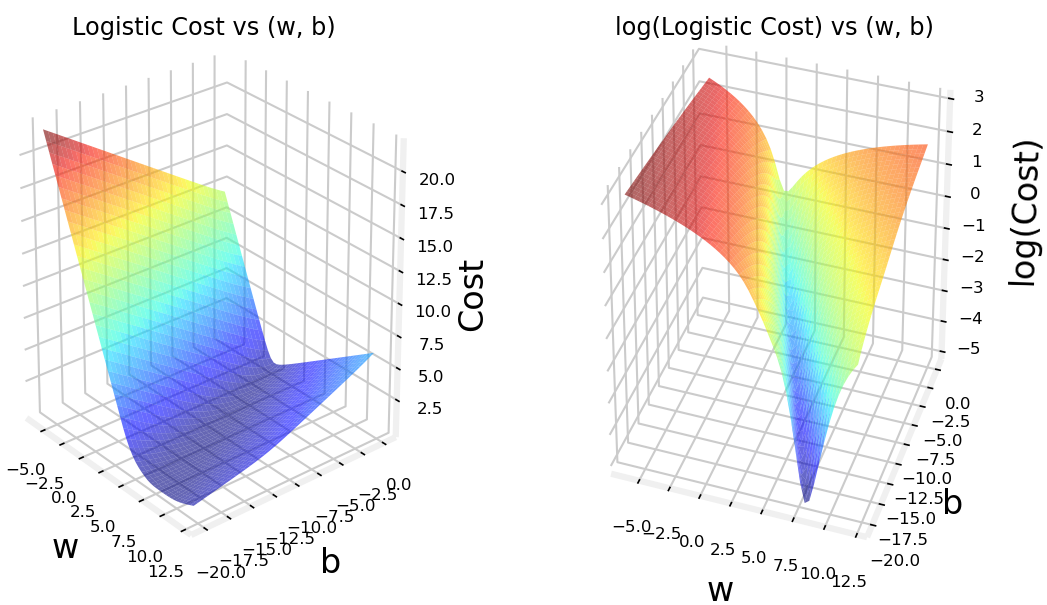

### 简化的逻辑回归代价函数

确实,我的版本还是要用到幂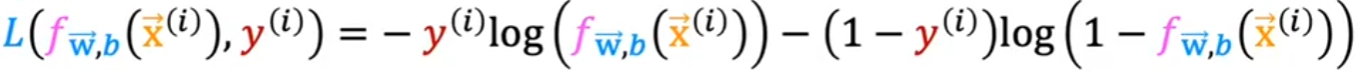

### 逻辑回归的梯度下降

$$\begin{align*}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)}  \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) 
\end{align*}$$

### 过拟合

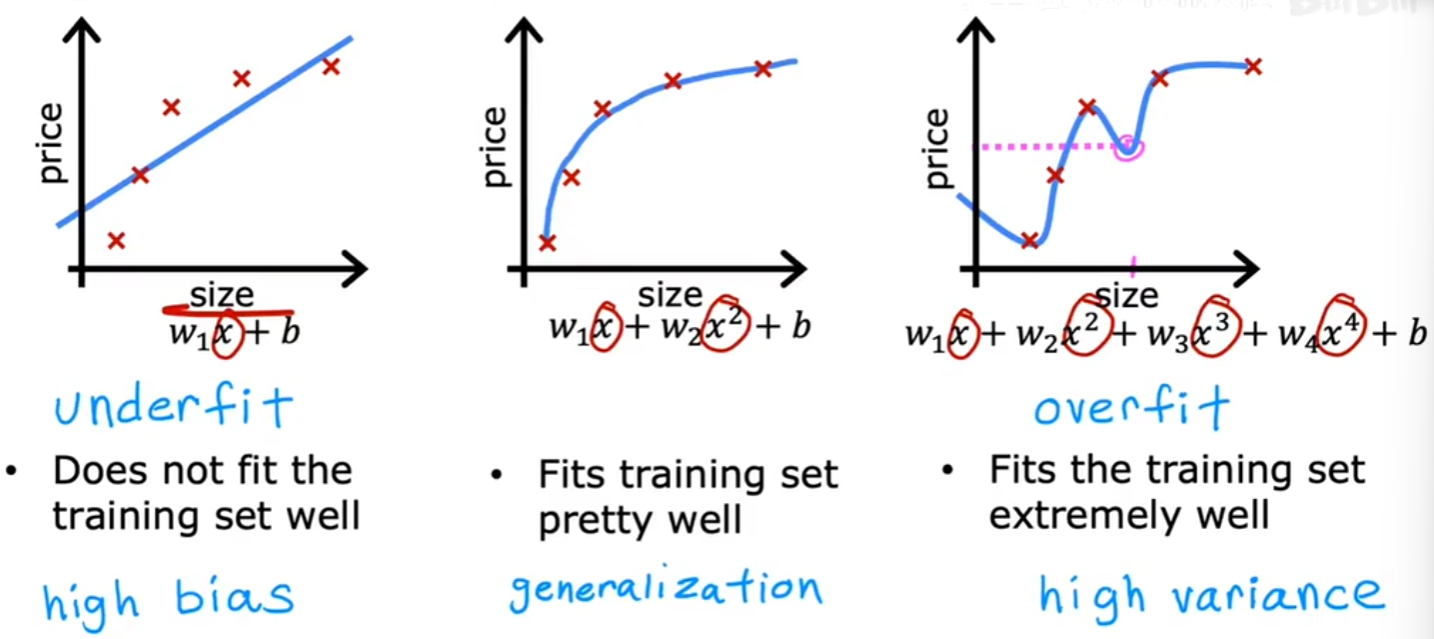

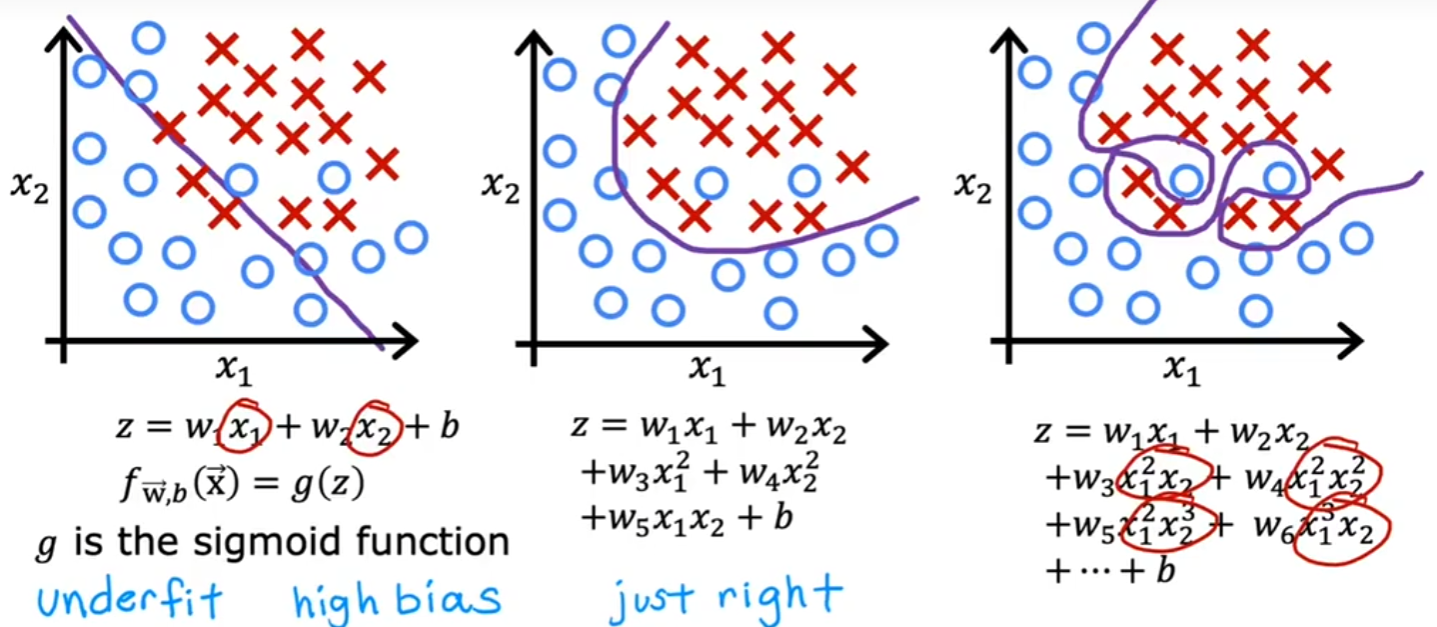

### 解决过拟合

1.增加数据量,说白了就是数据量少,机器只能自己乱开脑洞<br>
2.特征选择,比如说你有100个特征,但是里面有一些不好的数据(房子周围狗的数量这一类无关的)，不能让他的权重大(甚至是消除这个特征(权重为0))

3.正则化不是消除特征,而是让一部分权重尽可能小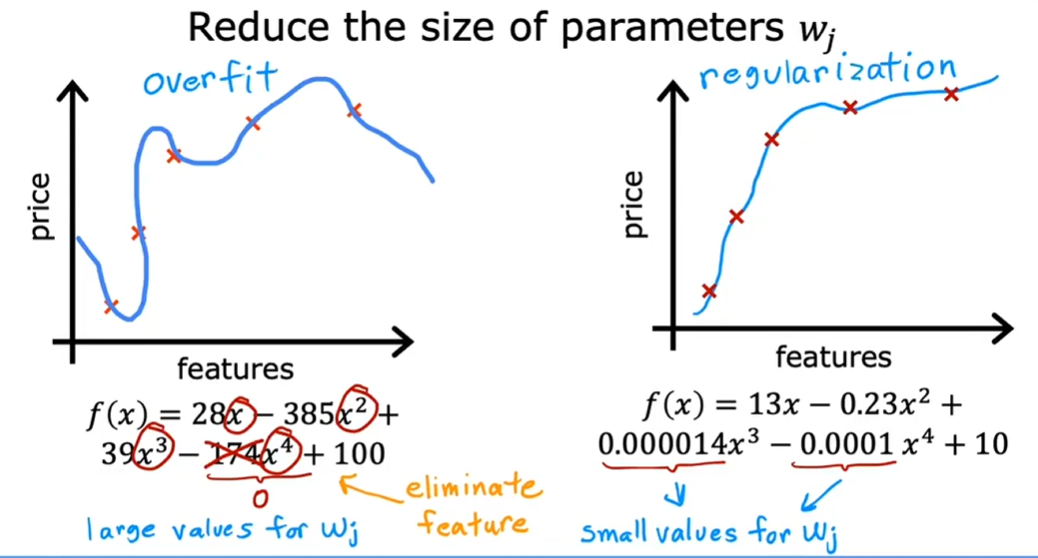

### 正则化的成本函数

$$J(w,b)=\frac{1}{2m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)})-y^{(i)})^2+\frac{\lambda}{2m}\sum_{j=1}^{n}w^2_{j}$$

$\lambda>0$是正则化参数,一般不对$b$进行正则化

### 正则化

#### 线性回归:

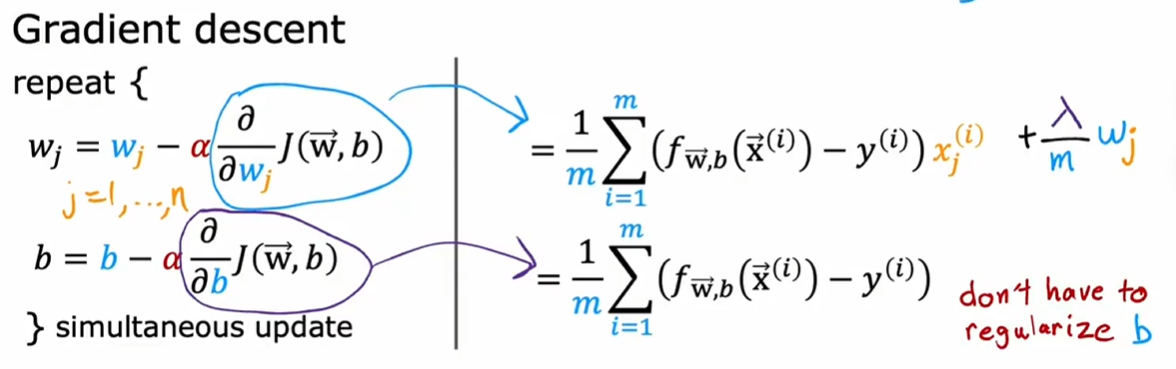

我们如果进行一些变形:$$w_{new}=(1-\alpha\frac{\lambda}{m})w-\alpha\frac{1}{m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)})-y^{(i)})x^{(i)}$$

旧的w的系数是一个非常接近1的数(一般情况),意思是每次迭代我们稍微缩小一下旧的w再加上梯度

#### 逻辑回归

$$L(f_{\boldsymbol {w},b}(\boldsymbol {x}^{(i)}),y^{(i)})=-\log{(y^{(i)}+(-1)^{y^{(i)}-1}f_{\boldsymbol {w},b}(\boldsymbol {x}^{(i)}))}+\frac{\lambda}{2m}\sum_{j=1}^{n}w^2_{j}$$